In [1]:
# !pip install catboost

In [2]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import  LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
#from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

In [3]:
#Importing Data
df = pd.read_csv("Data/Airbnb_Data.csv")

In [4]:
df

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,14549287,4.605170,Apartment,Private room,{},1,1.0,Real Bed,flexible,False,...,40.709025,-73.939405,one room bushwick,Williamsburg,0,NaN,https://a0.muscache.com/im/pictures/55162426/6...,11206.0,1.0,1.0
74107,13281809,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,...,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16,93.0,https://a0.muscache.com/im/pictures/2b86560b-a...,90254,2.0,4.0
74108,18688039,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,...,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206.0,2.0,2.0
74109,17045948,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,...,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,NaN,https://a0.muscache.com/im/pictures/b3971b63-0...,10011,0.0,2.0


In [5]:
#Data Exploration
df.shape

(74111, 29)

In [6]:
df.columns

Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

In [7]:
df.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [9]:
df.dtypes

id                          int64
log_price                 float64
property_type              object
room_type                  object
amenities                  object
accommodates                int64
bathrooms                 float64
bed_type                   object
cancellation_policy        object
cleaning_fee                 bool
city                       object
description                object
first_review               object
host_has_profile_pic       object
host_identity_verified     object
host_response_rate         object
host_since                 object
instant_bookable           object
last_review                object
latitude                  float64
longitude                 float64
name                       object
neighbourhood              object
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url              object
zipcode                    object
bedrooms                  float64
beds                      float64
dtype: object

In [10]:
index= ["host_response_rate","property_type", "room_type","accommodates","bathrooms","bed_type", "cancellation_policy", "cleaning_fee",
       "city","instant_bookable", "beds", "bedrooms", "neighbourhood","first_review", "last_review","zipcode",
       "name","host_since","thumbnail_url", "latitude", "longitude", 
        "host_has_profile_pic", "host_identity_verified"]

for i in index:
    
    print(df[i].value_counts(), "\n")
    print("---------------------------------------------------------------")

host_response_rate
100%    43254
90%      2277
80%      1113
0%        883
50%       611
        ...  
39%         1
15%         1
31%         1
21%         1
6%          1
Name: count, Length: 80, dtype: int64 

---------------------------------------------------------------
property_type
Apartment             49003
House                 16511
Condominium            2658
Townhouse              1692
Loft                   1244
Other                   607
Guesthouse              498
Bed & Breakfast         462
Bungalow                366
Villa                   179
Dorm                    142
Guest suite             123
Camper/RV                94
Timeshare                77
Cabin                    72
In-law                   71
Hostel                   70
Boutique hotel           69
Boat                     65
Serviced apartment       21
Tent                     18
Castle                   13
Vacation home            11
Yurt                      9
Hut                       8
Treehouse

In [11]:
#Data processing

#handling missing values

for column in df.columns:
    if df[column].isnull().sum() !=0: 
        print("========================================")
        print("\n{} :- {},  dtypes : {}".format(column,df[column].isnull().sum(),df[column].dtypes))


bathrooms :- 200,  dtypes : float64

first_review :- 15864,  dtypes : object

host_has_profile_pic :- 188,  dtypes : object

host_identity_verified :- 188,  dtypes : object

host_response_rate :- 18299,  dtypes : object

host_since :- 188,  dtypes : object

last_review :- 15827,  dtypes : object

neighbourhood :- 6872,  dtypes : object

review_scores_rating :- 16722,  dtypes : float64

thumbnail_url :- 8216,  dtypes : object

zipcode :- 966,  dtypes : object

bedrooms :- 91,  dtypes : float64

beds :- 131,  dtypes : float64


In [12]:
df.last_review.fillna(method="ffill", inplace=True) #Điền giá trị null bằng giá trị trước đó 

In [13]:
df.first_review.fillna(method="ffill",inplace=True)

In [14]:
df.host_since.fillna(method="ffill",inplace=True) #với các giá trị text thì nên lấy giá trị trước đó điền vào vì các giá trị text thường không có sự khác biệt nhiều giữa các giá trị liên tiếp nhau

<Axes: xlabel='bathrooms', ylabel='Density'>

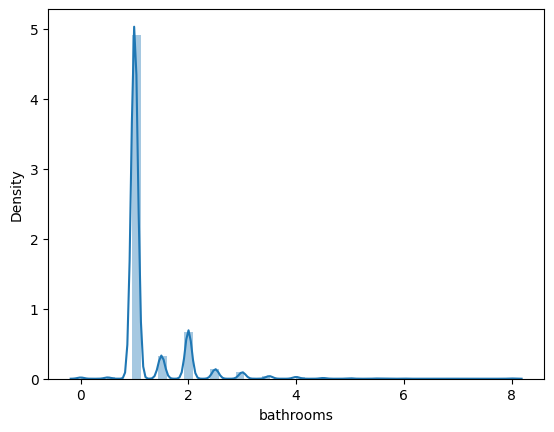

In [15]:
sns.distplot(df.bathrooms)

In [16]:
#Giá trị số có thể lấy average hoặc median để điền vào các giá trị null, nhưng với các giá trị text thì nên lấy giá trị trước đó điền vào vì các giá trị text thường không có sự khác biệt nhiều giữa các giá trị liên tiếp nhau

In [17]:
df["bathrooms"].fillna(df["bathrooms"].median(), inplace=True)

<Axes: xlabel='review_scores_rating', ylabel='Density'>

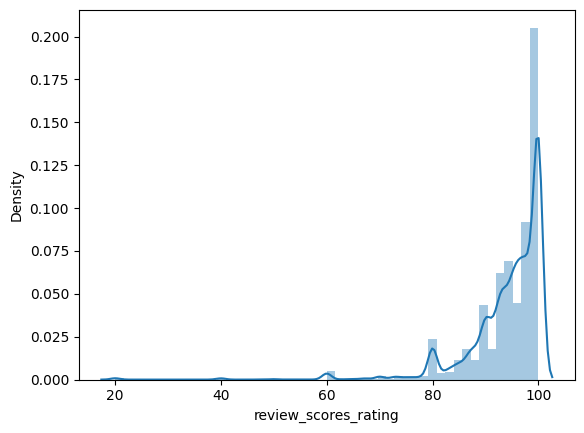

In [18]:
sns.distplot(df["review_scores_rating"])

In [19]:
df.review_scores_rating.fillna(0, inplace=True) #Điền giá trị null bằng 0

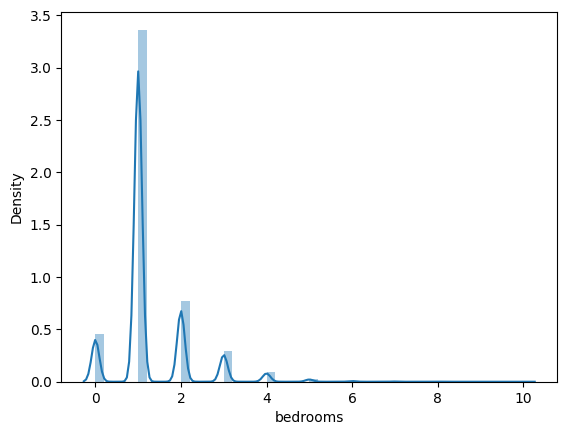

In [20]:
sns.distplot(df["bedrooms"])
plt.show()

In [21]:
df["bedrooms"] = df['bedrooms'].fillna((df["bathrooms"].median()))

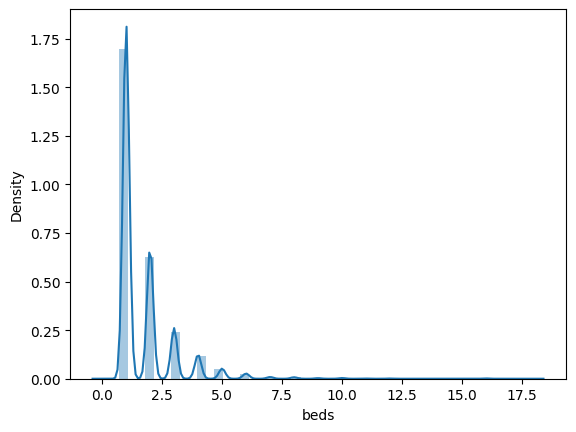

In [22]:
sns.distplot(df["beds"])
plt.show()

In [23]:
df["beds"] = df["beds"].fillna((df["bathrooms"].median()))

In [24]:
amenities_counts=[]
for i in df["amenities"]:
    amenities_counts.append(len(i.split(",")))


In [25]:
df['amenities'] = amenities_counts

In [26]:
pd.set_option("display.max_columns", None)

In [27]:
df

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,9,3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,15,7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,19,5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,15,4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,2017-04-30,t,t,NaN,2015-04-19,f,2017-09-14,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,0.0,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,12,2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,14549287,4.605170,Apartment,Private room,1,1,1.0,Real Bed,flexible,False,NYC,one room in bushwick apt,2016-03-25,t,t,NaN,2013-03-24,f,2017-02-19,40.709025,-73.939405,one room bushwick,Williamsburg,0,0.0,https://a0.muscache.com/im/pictures/55162426/6...,11206.0,1.0,1.0
74107,13281809,5.043425,Apartment,Entire home/apt,16,4,2.0,Real Bed,moderate,True,LA,"Located on the Pacific Coast Highway, this apa...",2016-08-15,t,f,100%,2016-05-03,f,2017-04-15,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16,93.0,https://a0.muscache.com/im/pictures/2b86560b-a...,90254,2.0,4.0
74108,18688039,5.220356,Apartment,Entire home/apt,31,5,1.0,Real Bed,moderate,True,NYC,A modern apartment located in East Williamsbur...,2015-01-03,t,t,100%,2012-01-05,t,2017-09-10,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206.0,2.0,2.0
74109,17045948,5.273000,Apartment,Entire home/apt,15,2,1.0,Real Bed,strict,True,NYC,"Fully renovated, designer's studio located in ...",2015-01-03,t,f,100%,2017-09-17,t,2017-09-10,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,0.0,https://a0.muscache.com/im/pictures/b3971b63-0...,10011,0.0,2.0


In [28]:
#Data Visualisation

In [29]:
# Function to plot catplot graphs
def plot_catplot(h,v,he,a):
    sns.set(font_scale=1.5)
    sns.catplot(x=h,kind=v,data=df,height=he, aspect = a)
    
# Function to plot catplot graphs
def plot_piechart(h):
    sns.set(font_scale=1.5)
    fig = plt.figure(figsize=(5,5)) #tạo một figure - có thể hiểu là toàn bộ khung/canvas chứa biểu đồ width = 5 inch, height = 5 inch
    ax = fig.add_axes([0,0,1,1])
    ax.axis('equal')
    langs = list(df[h].unique())
    students =list(df[h].value_counts())
    ax.pie(students, labels = langs,autopct='%1.2f%%')
    plt.show()

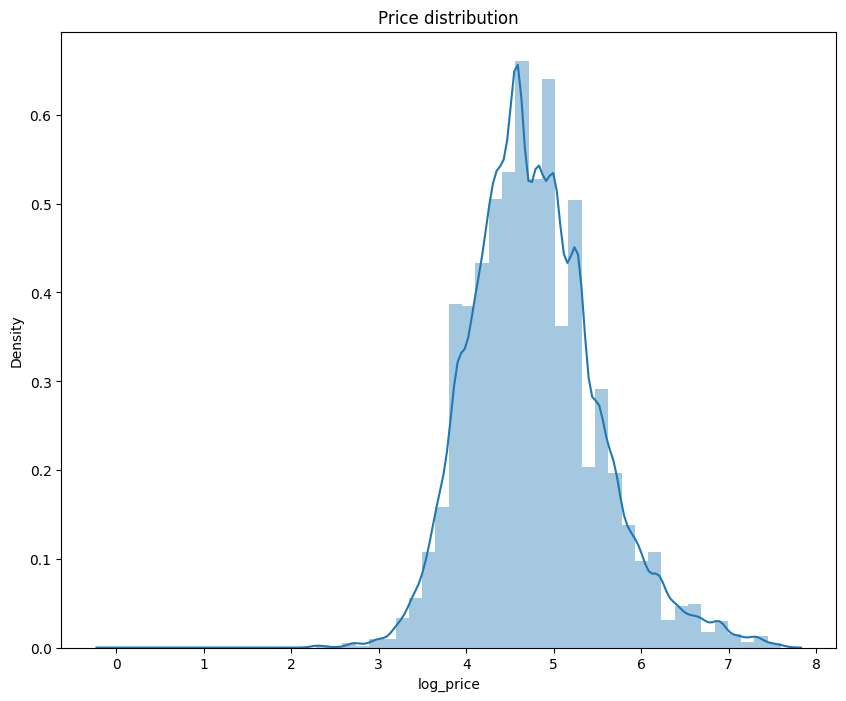

In [30]:
plt.figure(figsize = (10, 8))
sns.distplot(df["log_price"])
plt.title('Price distribution')
plt.show()

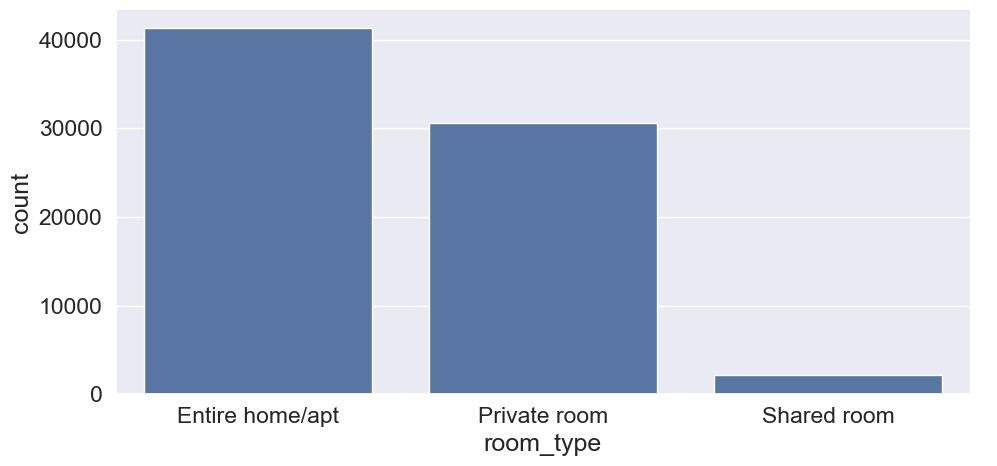

In [31]:
plot_catplot("room_type", "count", 5, 2)

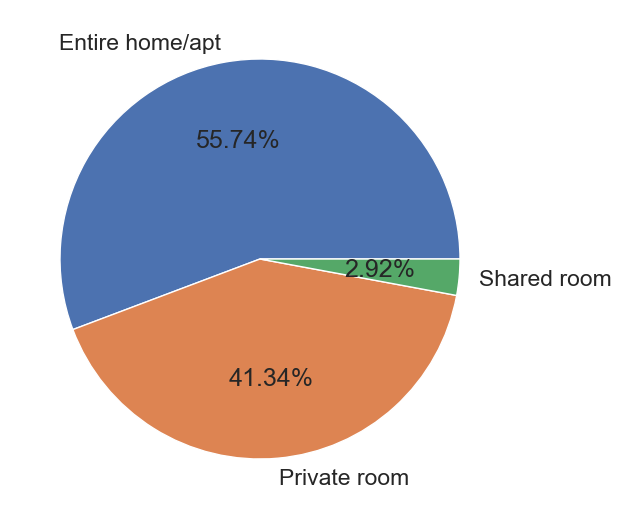

In [32]:

plot_piechart("room_type") 

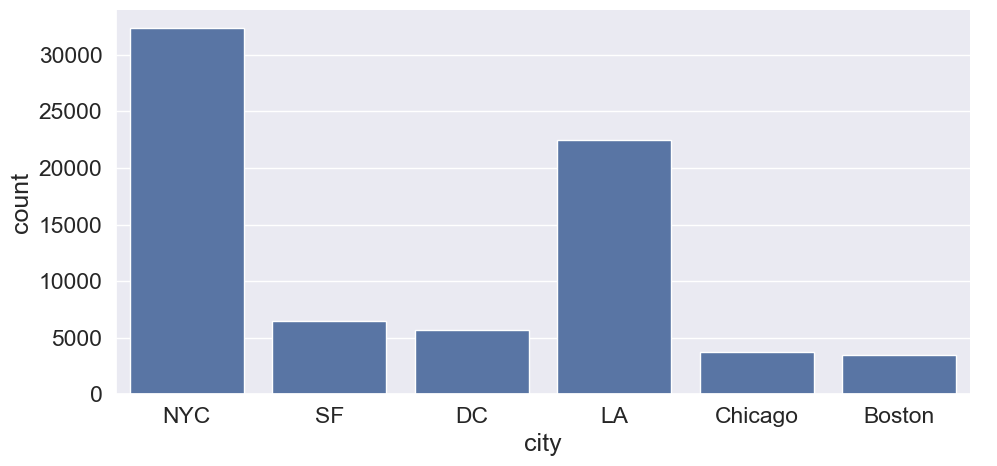

In [33]:
plot_catplot("city","count", 5, 2)

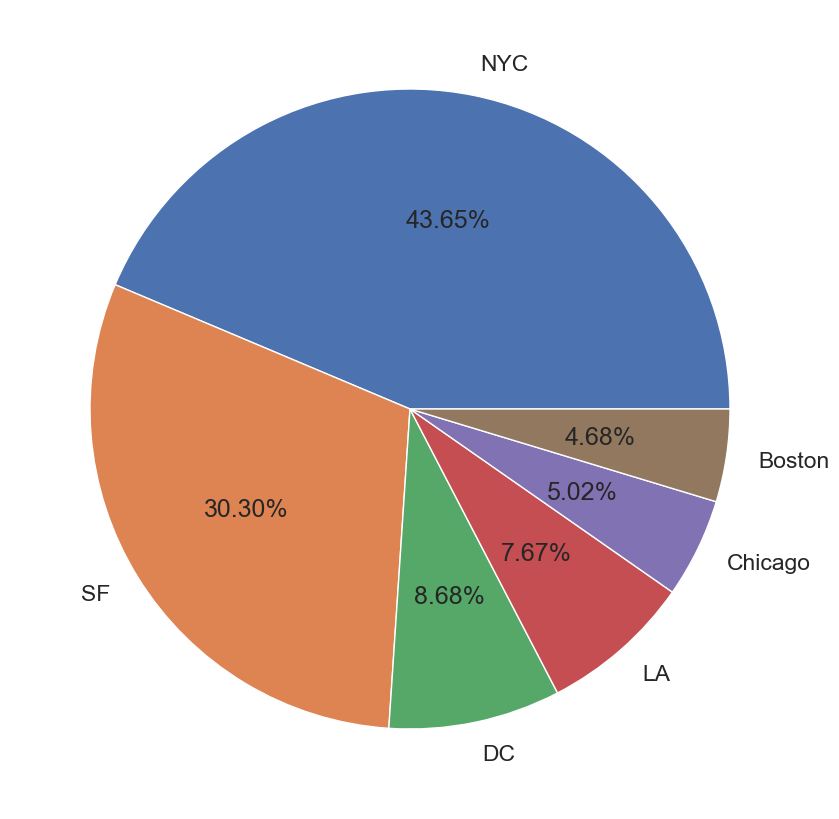

In [34]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_axes([0,0,1,1])
ax.axis('equal')
langs = list(df.city.unique())
students =list(df.city.value_counts())
ax.pie(students, labels = langs,autopct='%1.2f%%')
plt.show()

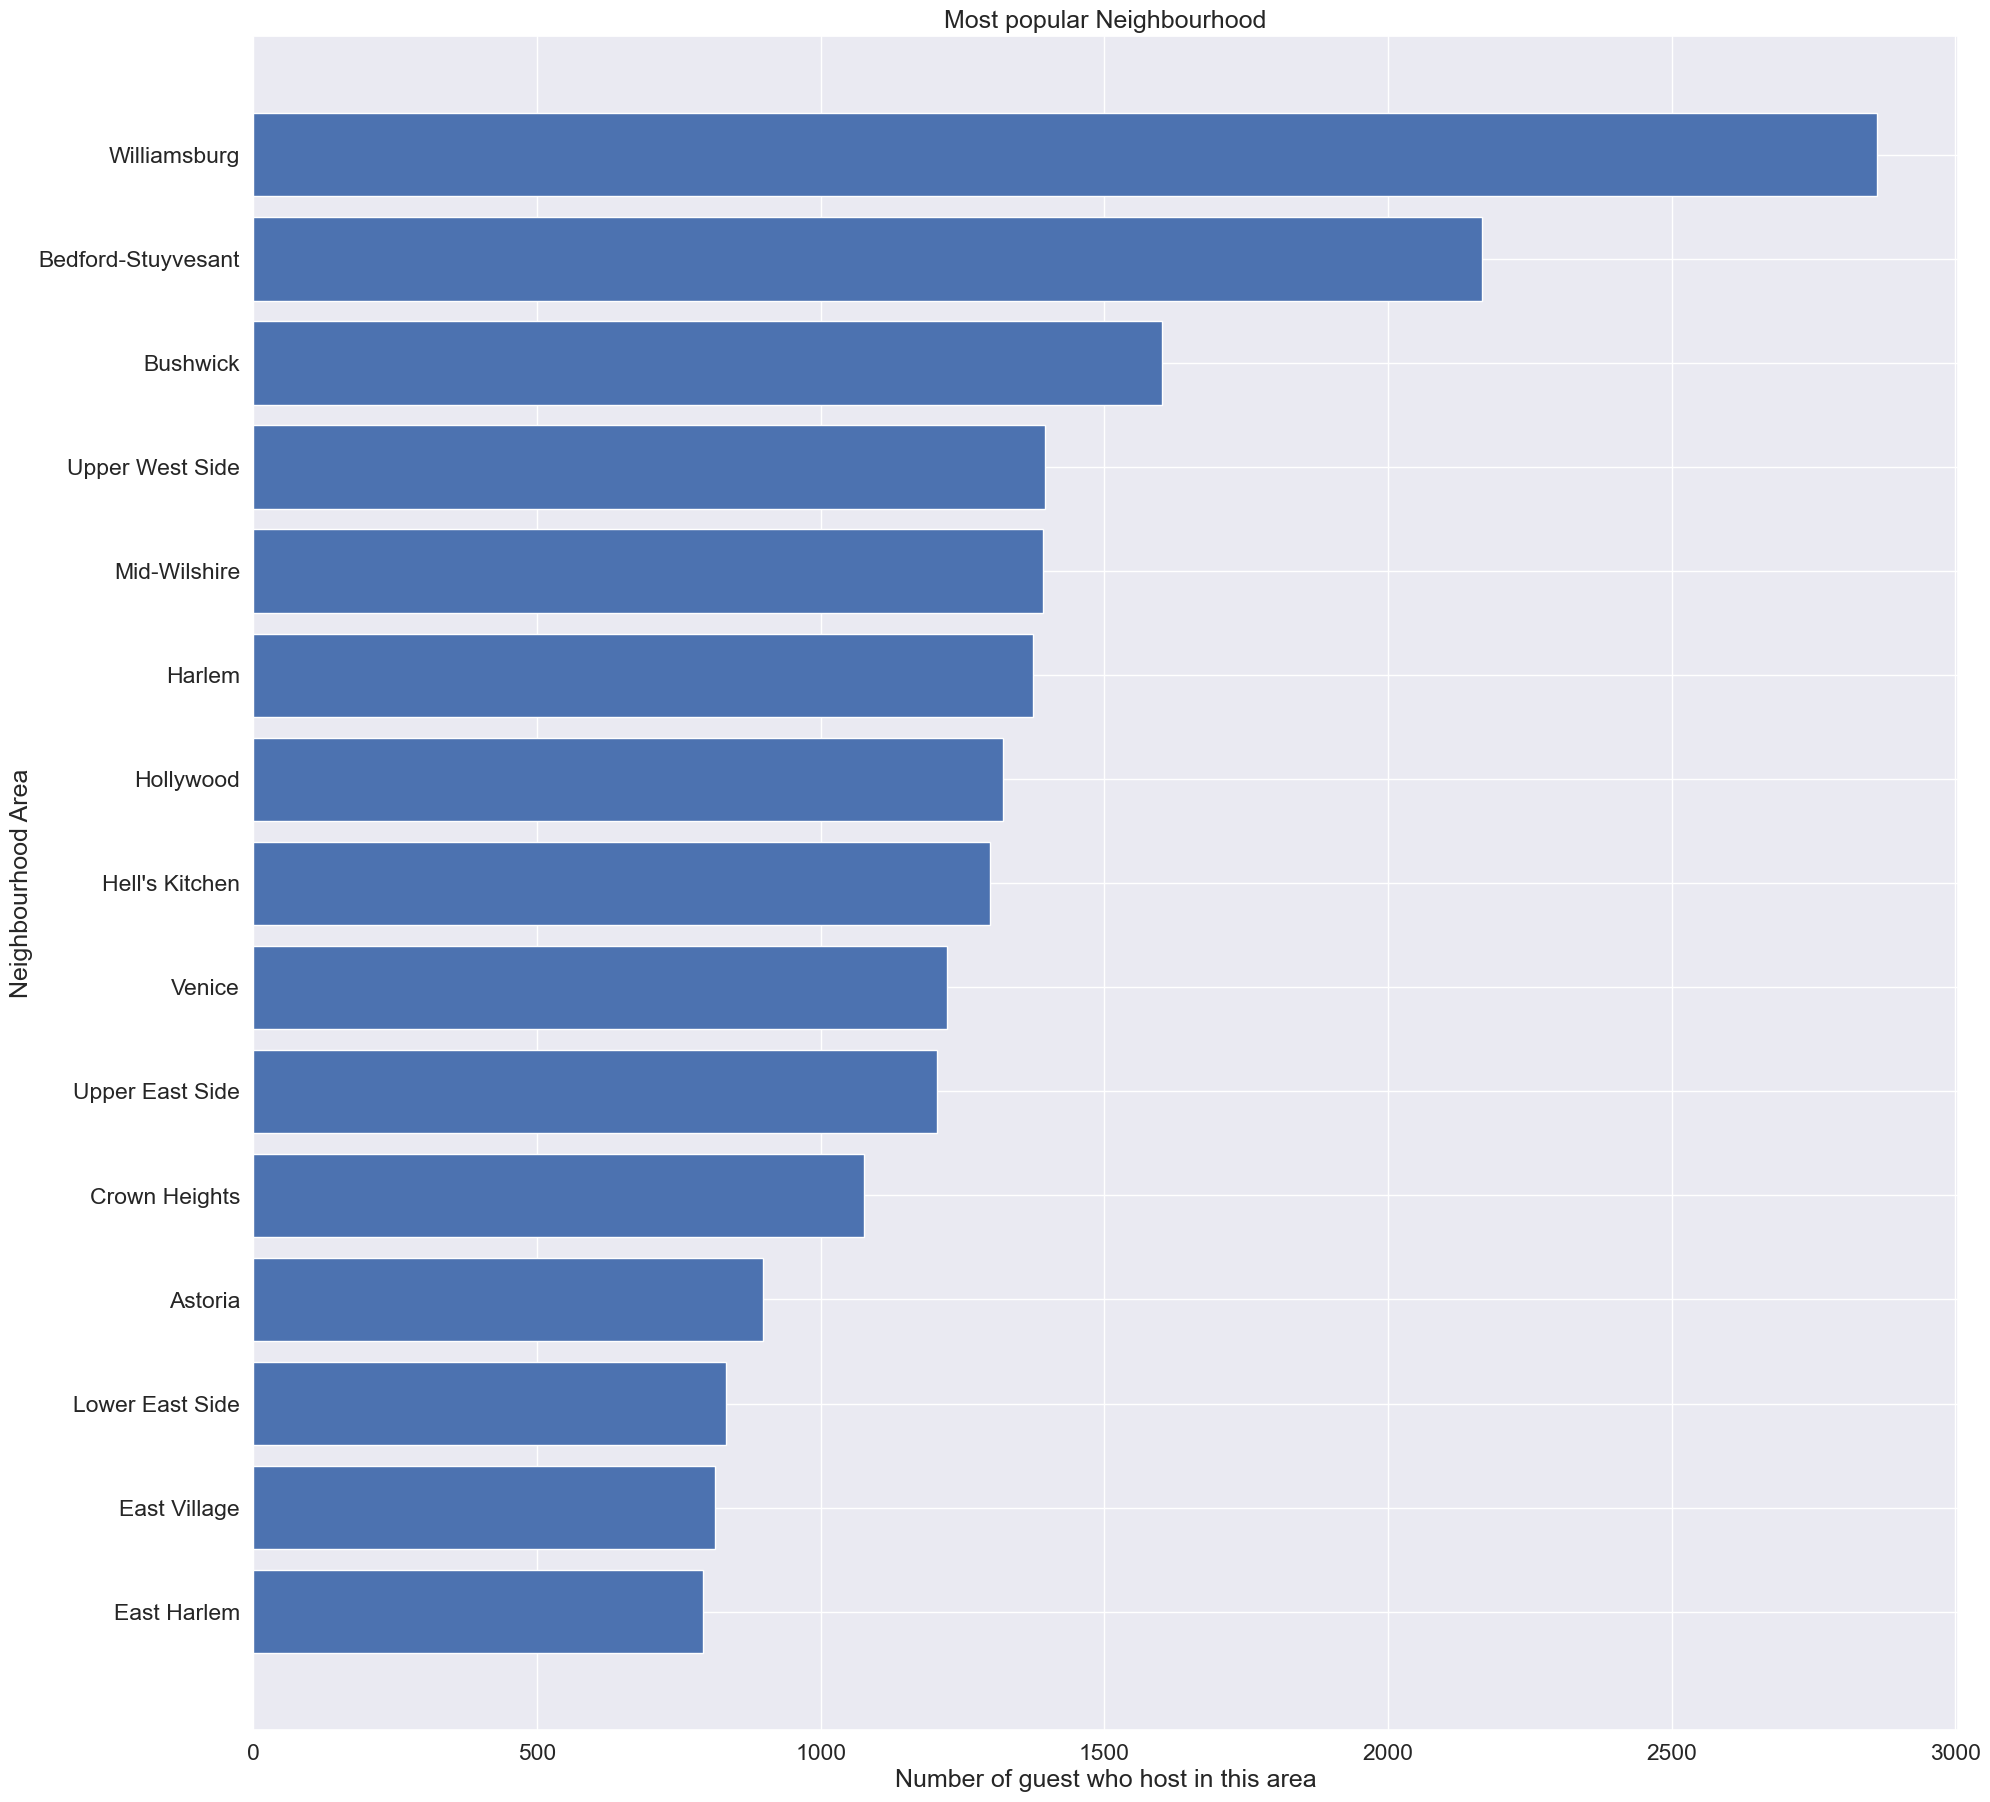

In [35]:
data = df.neighbourhood.value_counts()[:15]
plt.figure(figsize=(22,22))
x = list(data.index)
y = list(data.values)
x.reverse()
y.reverse()

plt.title("Most popular Neighbourhood")
plt.ylabel("Neighbourhood Area")
plt.xlabel("Number of guest who host in this area")

plt.barh(x,y)
plt.show()

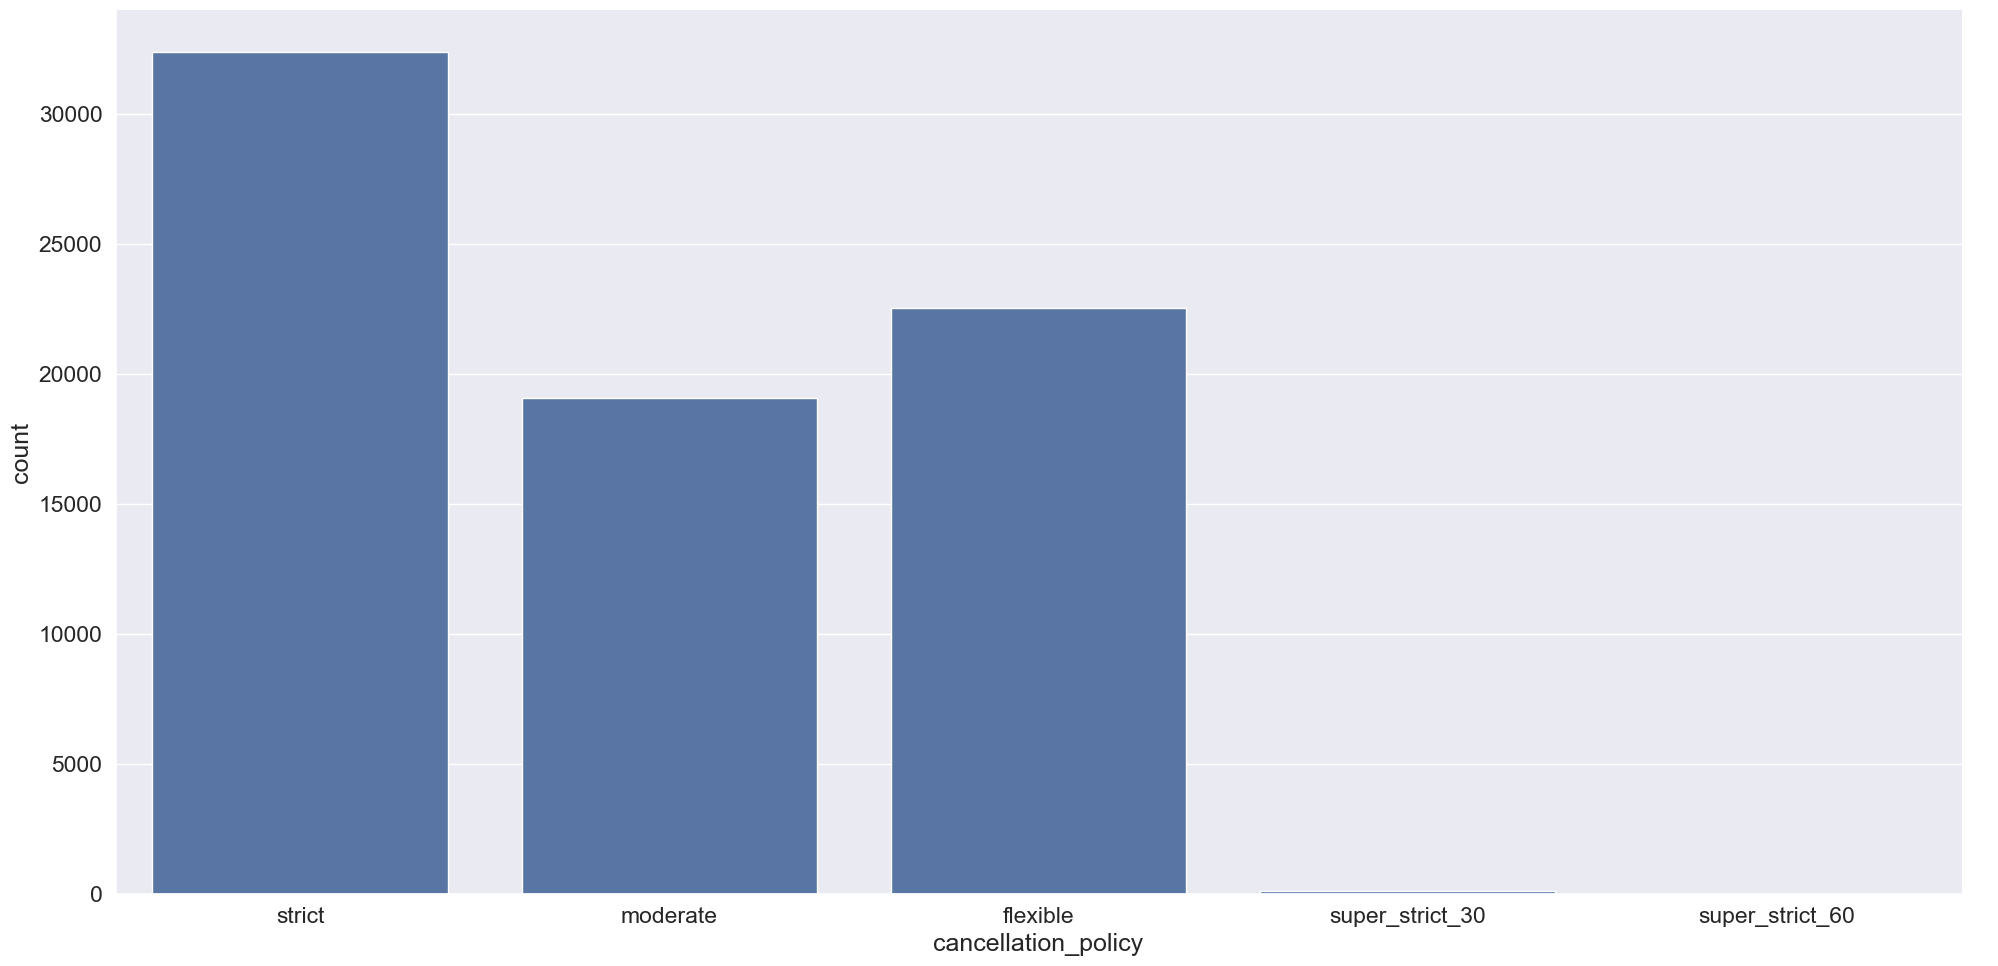

In [36]:
plot_catplot("cancellation_policy","count",10, 2)

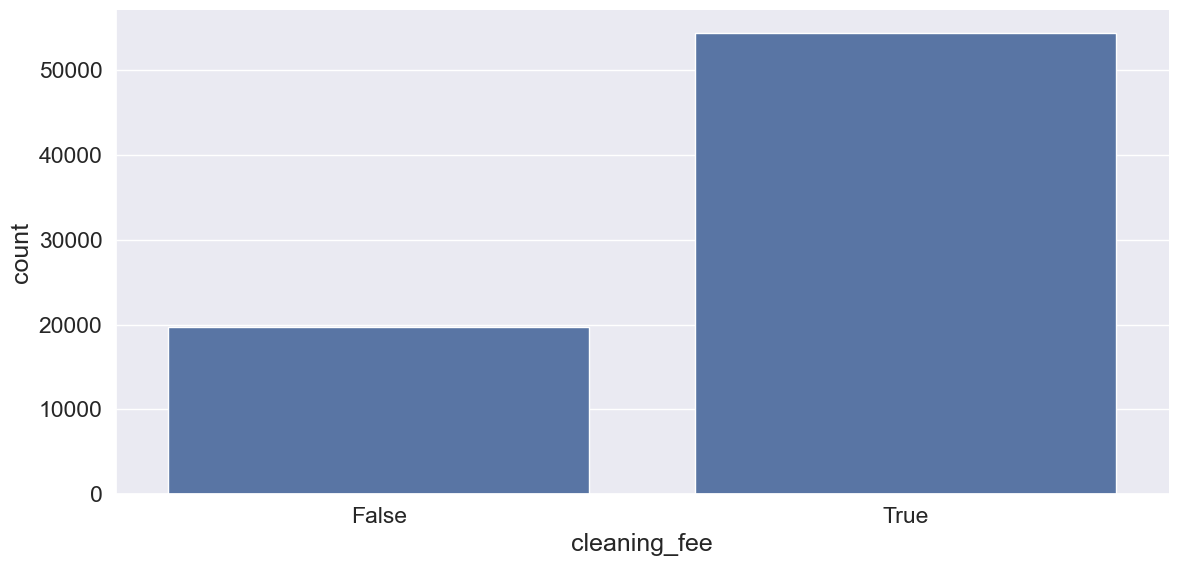

In [37]:
plot_catplot("cleaning_fee","count",6,2)

In [38]:
def plot_violinplot(h,v):
    plt.figure(figsize=(15,8))
    sns.set(font_scale=1.5)
    sns.violinplot(data=df, x=h, y=v, palette='GnBu_d')
    plt.title('Density and distribution of prices ', fontsize=15)
    plt.xlabel(h)
    plt.ylabel(v)

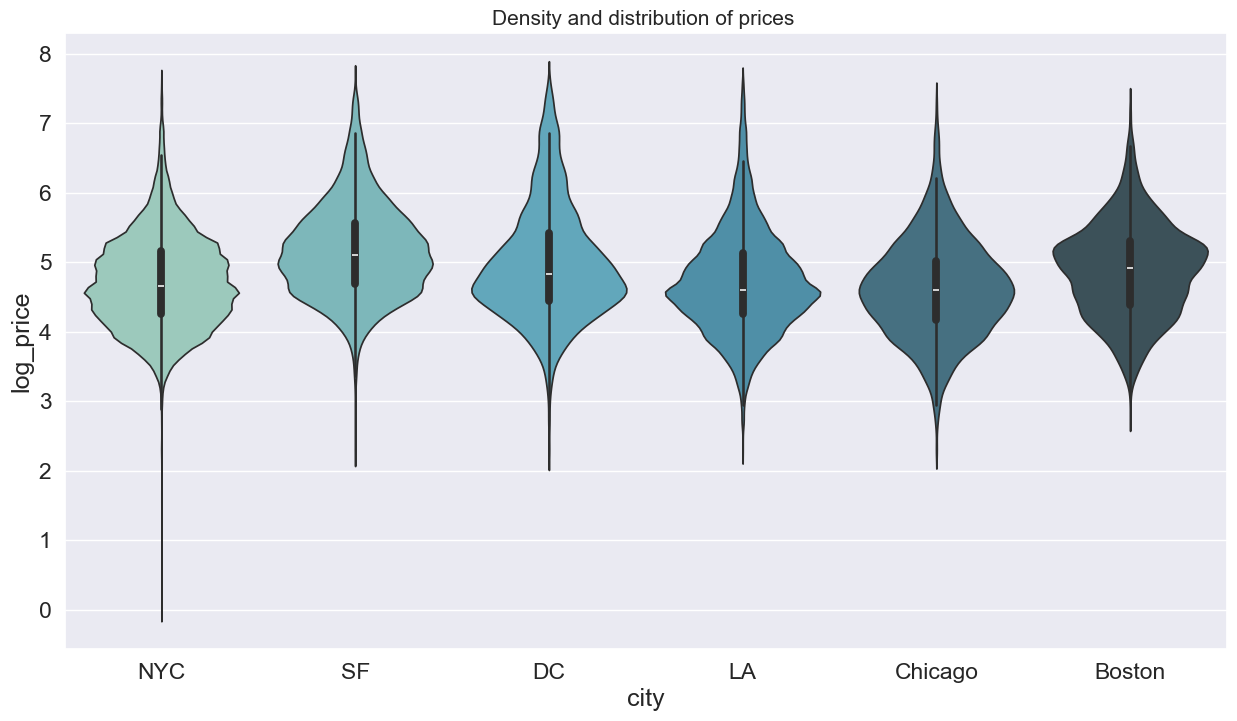

In [39]:
plot_violinplot("city","log_price")

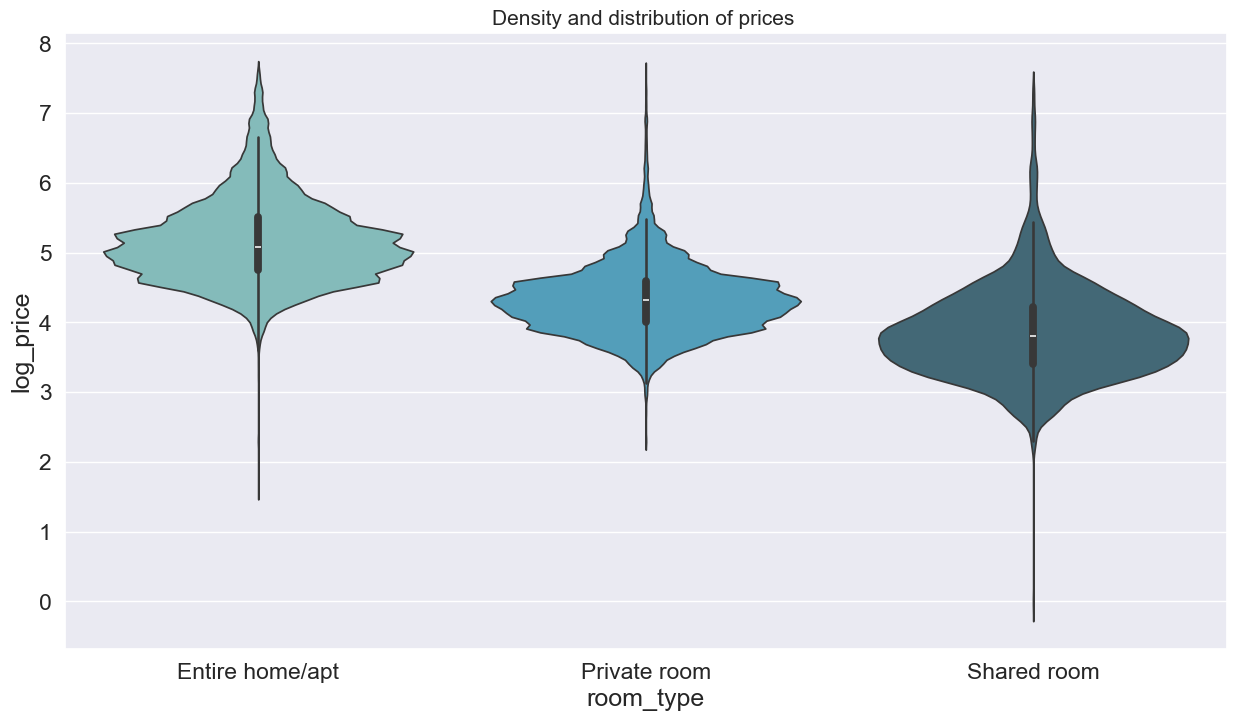

In [40]:
plot_violinplot("room_type","log_price")

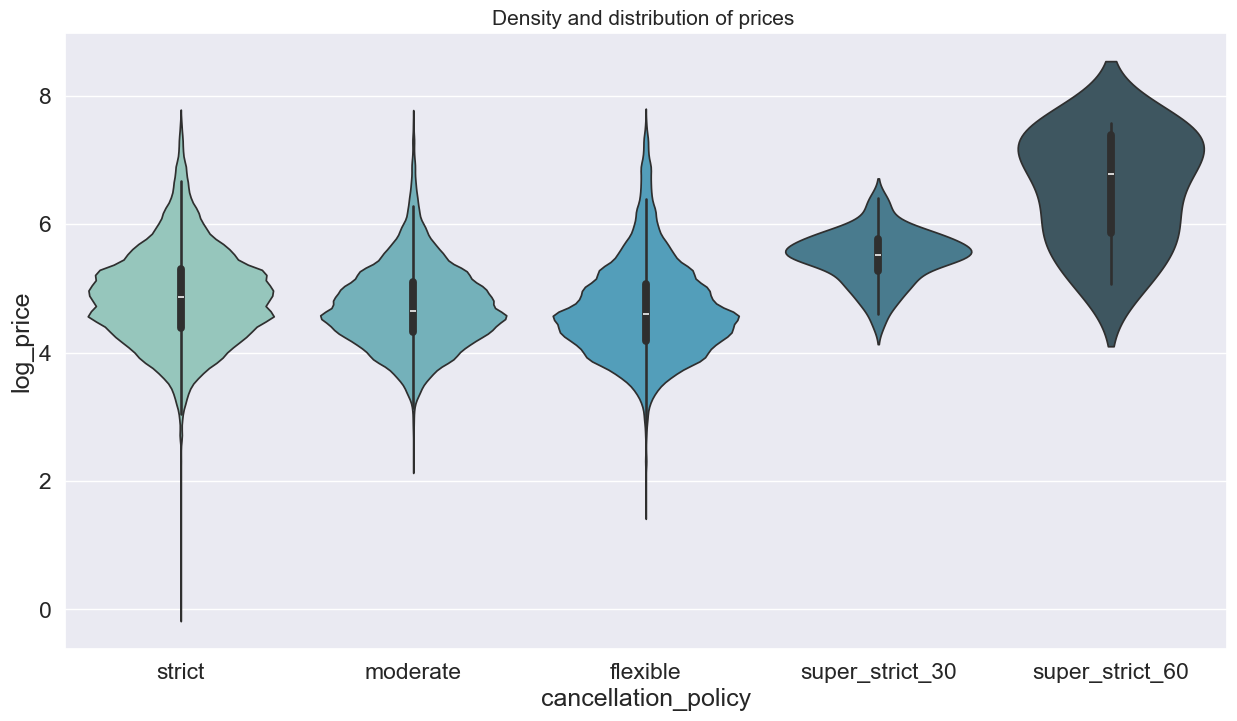

In [41]:
plot_violinplot("cancellation_policy","log_price")

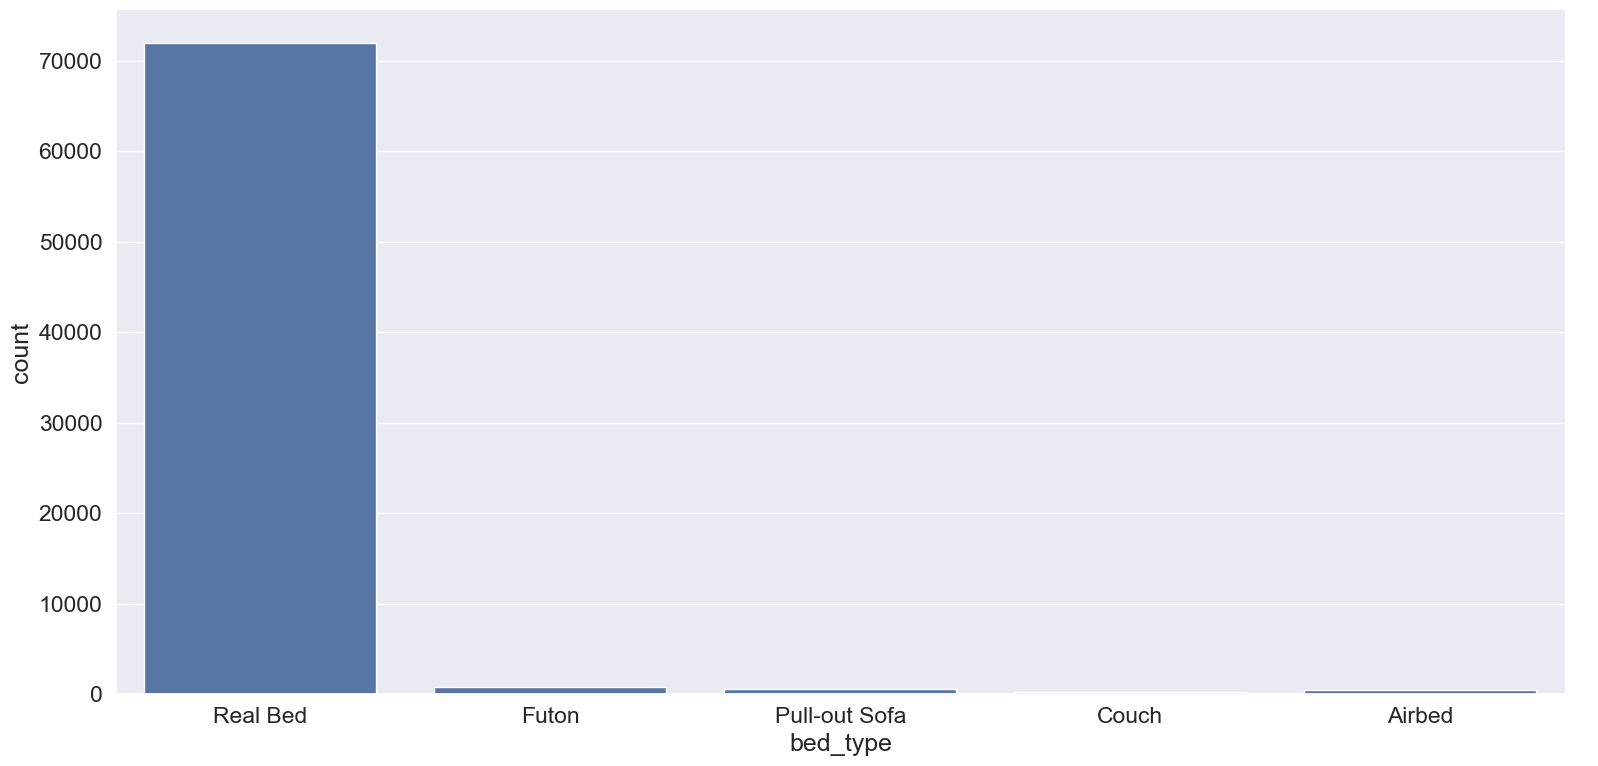

In [42]:
plot_catplot("bed_type","count",8, 2)

In [43]:
categorical_col = []
numerical_col = []

for column in df.columns:
    
    if df[column].dtypes != "float64" and df[column].dtypes !="int64":
        categorical_col.append(column)
    else:
        numerical_col.append(column)

In [44]:
numerical_col

['id',
 'log_price',
 'amenities',
 'accommodates',
 'bathrooms',
 'latitude',
 'longitude',
 'number_of_reviews',
 'review_scores_rating',
 'bedrooms',
 'beds']

In [45]:
categorical_col

['property_type',
 'room_type',
 'bed_type',
 'cancellation_policy',
 'cleaning_fee',
 'city',
 'description',
 'first_review',
 'host_has_profile_pic',
 'host_identity_verified',
 'host_response_rate',
 'host_since',
 'instant_bookable',
 'last_review',
 'name',
 'neighbourhood',
 'thumbnail_url',
 'zipcode']

In [46]:
from sklearn.preprocessing import LabelEncoder #encodes categorical features as a number between 0 and n_classes-1
le = LabelEncoder()

In [47]:
for col in categorical_col:
    df[col] = le.fit_transform(df[col])

In [48]:
df

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,0,0,9,3,1.0,4,2,1,4,9972,2079,1,1,80,1069,0,926,40.696524,-73.991617,10464,77,2,100.0,32398,195,1.0,1.0
1,6304928,5.129899,0,0,15,7,1.0,4,2,1,4,19019,2492,1,0,2,2980,1,1358,40.766115,-73.989040,65672,252,6,93.0,16220,74,3.0,3.0
2,7919400,4.976734,0,0,19,5,1.0,4,1,1,4,55642,2395,1,1,2,2743,1,1349,40.808110,-73.943756,66396,247,10,92.0,32852,84,1.0,3.0
3,13418779,6.620073,17,0,15,4,1.0,4,0,1,5,63089,2395,1,1,80,2188,0,1349,37.772004,-122.431619,9387,325,0,0.0,33692,748,2.0,2.0
4,3808709,4.744932,0,0,12,2,1.0,4,1,1,2,15914,1676,1,1,2,2139,1,1114,38.925627,-77.034596,32068,119,4,40.0,65883,341,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,14549287,4.605170,0,1,1,1,1.0,4,0,0,4,72523,1994,1,1,80,1432,0,1142,40.709025,-73.939405,72348,605,0,0.0,25229,203,1.0,1.0
74107,13281809,5.043425,0,0,16,4,2.0,4,1,1,3,30741,2137,1,0,2,2568,0,1197,33.871549,-118.396053,59902,255,16,93.0,13695,515,2.0,4.0
74108,18688039,5.220356,0,0,31,5,1.0,4,1,1,4,4691,1547,1,1,2,988,1,1345,40.706749,-73.942377,43692,605,43,94.0,37484,203,2.0,2.0
74109,17045948,5.273000,0,0,15,2,1.0,4,2,1,4,21026,1547,1,0,2,3070,1,1345,40.738535,-74.000157,26450,592,0,0.0,51019,61,0.0,2.0


In [49]:
df.dtypes

id                          int64
log_price                 float64
property_type               int64
room_type                   int64
amenities                   int64
accommodates                int64
bathrooms                 float64
bed_type                    int64
cancellation_policy         int64
cleaning_fee                int64
city                        int64
description                 int64
first_review                int64
host_has_profile_pic        int64
host_identity_verified      int64
host_response_rate          int64
host_since                  int64
instant_bookable            int64
last_review                 int64
latitude                  float64
longitude                 float64
name                        int64
neighbourhood               int64
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url               int64
zipcode                     int64
bedrooms                  float64
beds                      float64
dtype: object

In [50]:
#HEATMAP

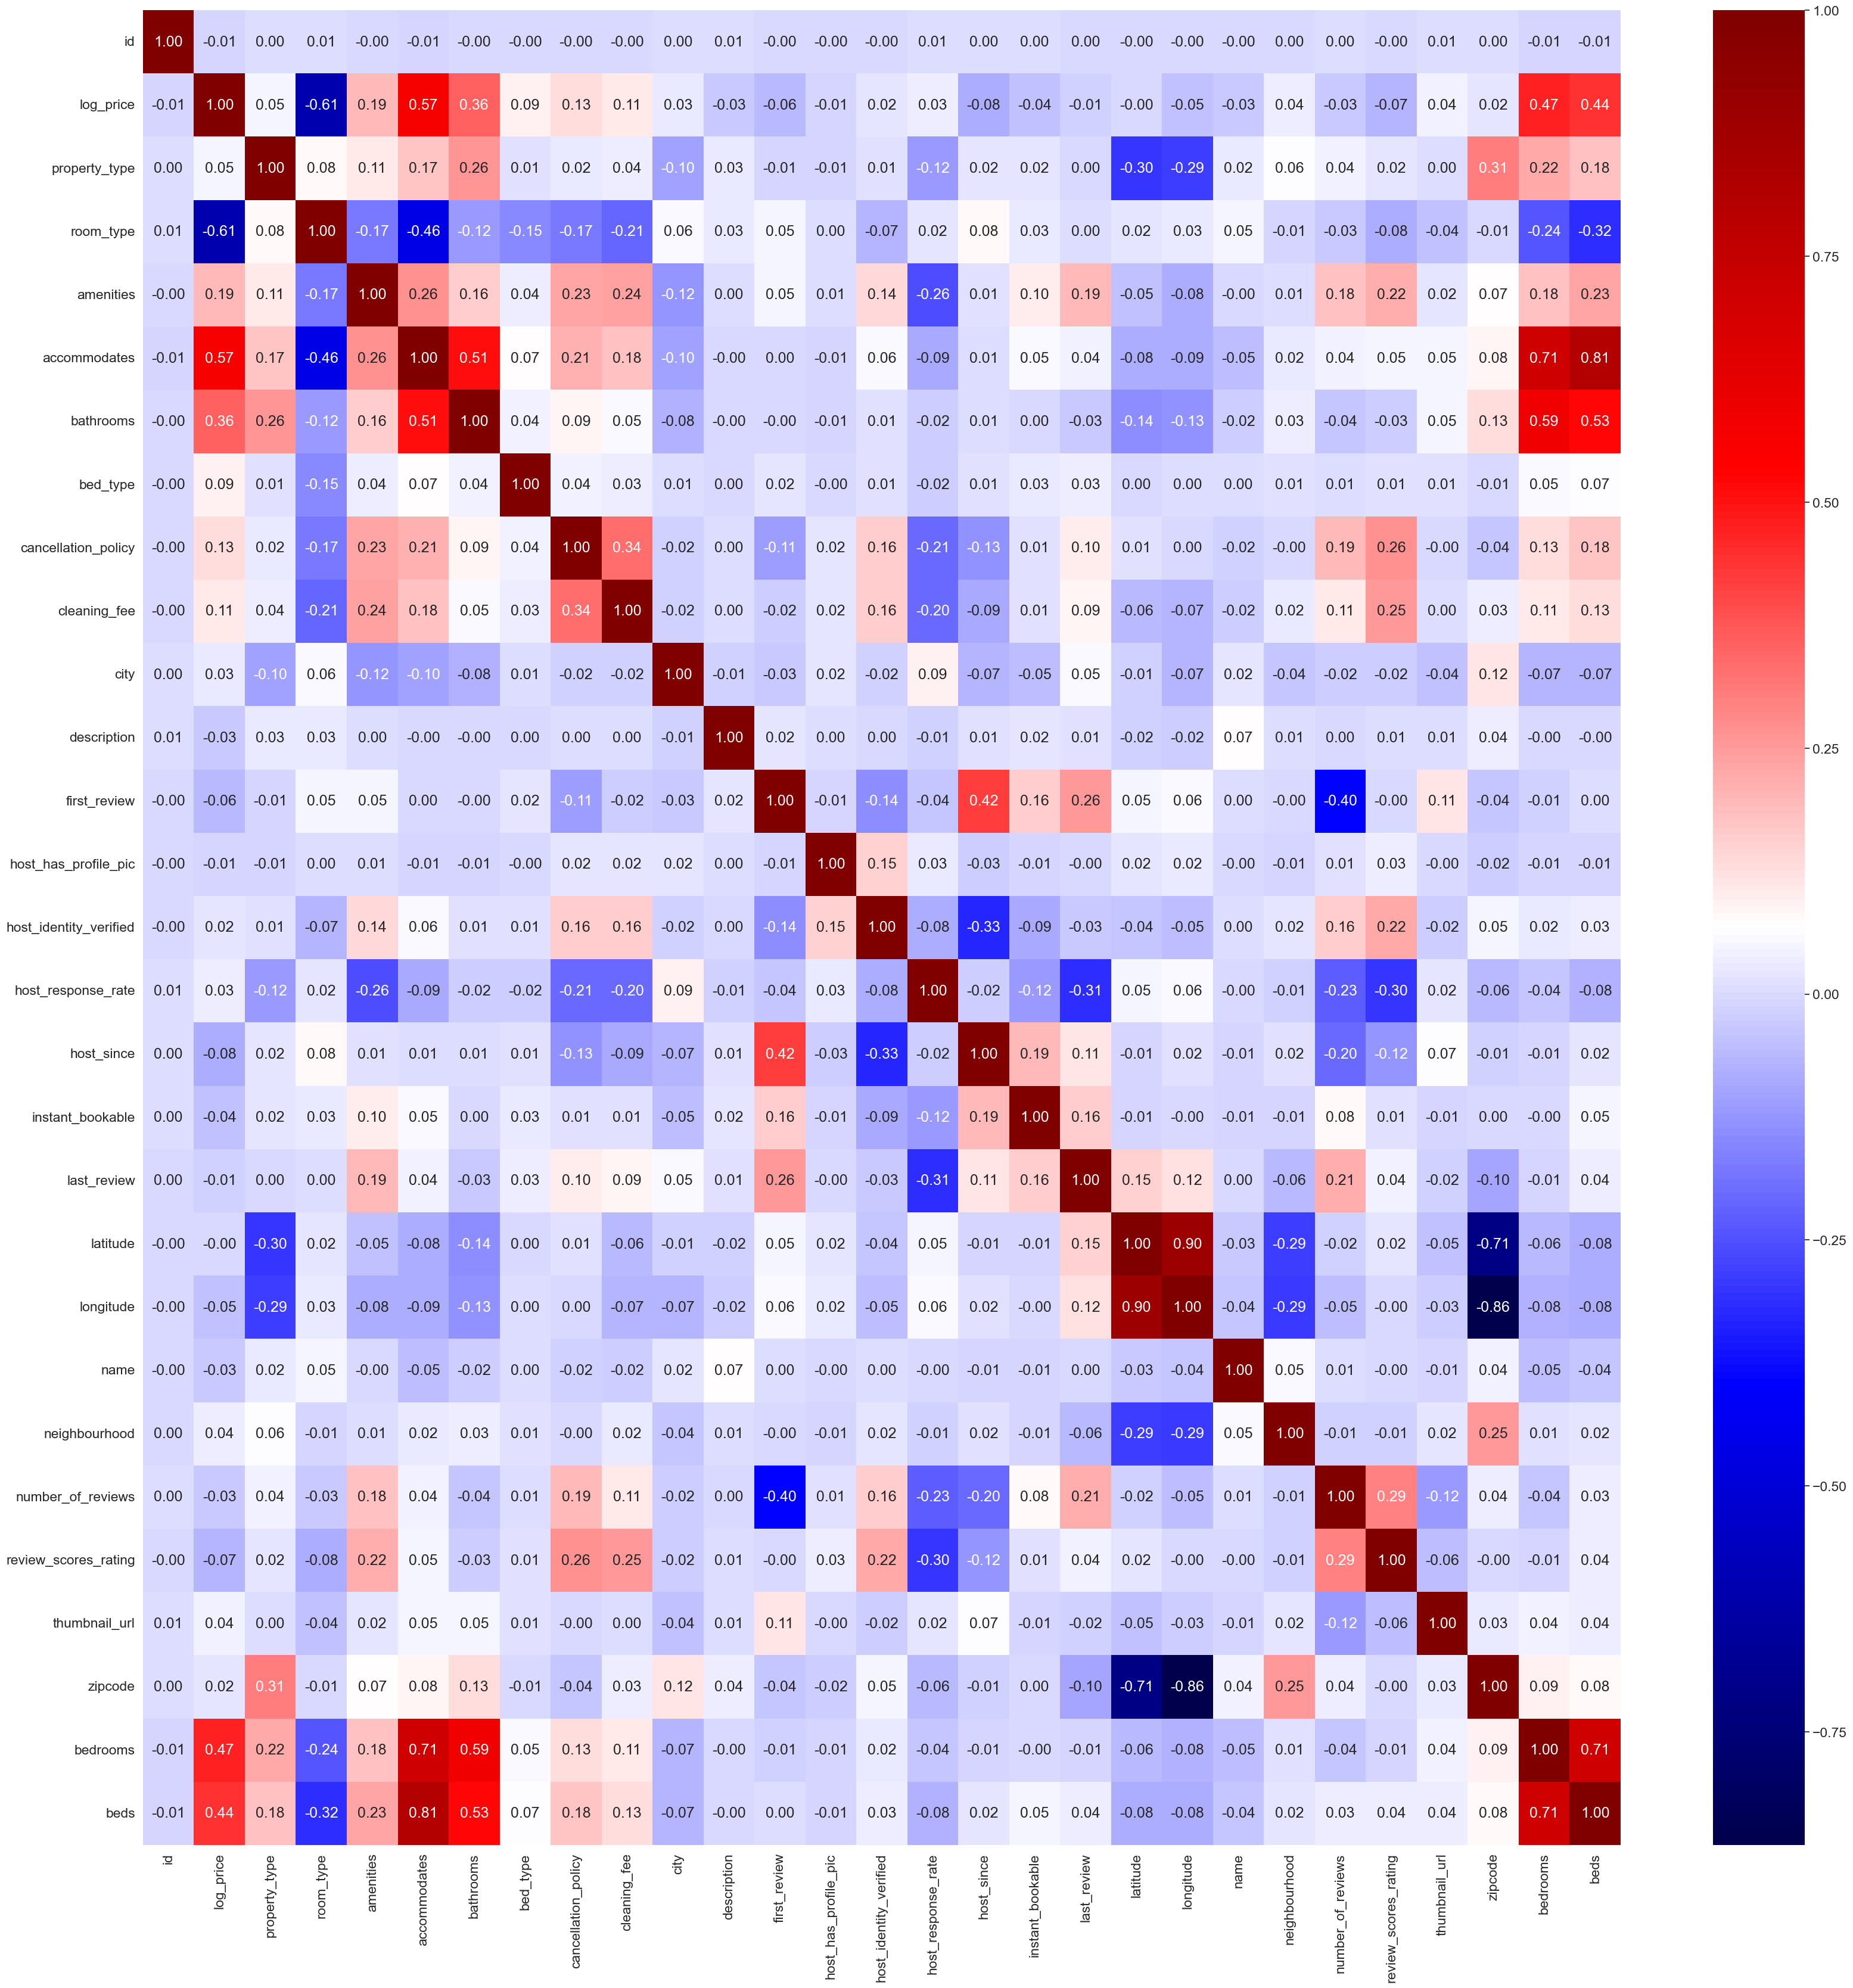

In [51]:
plt.figure(figsize = (40,40))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="seismic")
plt.show()

In [52]:
df

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,0,0,9,3,1.0,4,2,1,4,9972,2079,1,1,80,1069,0,926,40.696524,-73.991617,10464,77,2,100.0,32398,195,1.0,1.0
1,6304928,5.129899,0,0,15,7,1.0,4,2,1,4,19019,2492,1,0,2,2980,1,1358,40.766115,-73.989040,65672,252,6,93.0,16220,74,3.0,3.0
2,7919400,4.976734,0,0,19,5,1.0,4,1,1,4,55642,2395,1,1,2,2743,1,1349,40.808110,-73.943756,66396,247,10,92.0,32852,84,1.0,3.0
3,13418779,6.620073,17,0,15,4,1.0,4,0,1,5,63089,2395,1,1,80,2188,0,1349,37.772004,-122.431619,9387,325,0,0.0,33692,748,2.0,2.0
4,3808709,4.744932,0,0,12,2,1.0,4,1,1,2,15914,1676,1,1,2,2139,1,1114,38.925627,-77.034596,32068,119,4,40.0,65883,341,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,14549287,4.605170,0,1,1,1,1.0,4,0,0,4,72523,1994,1,1,80,1432,0,1142,40.709025,-73.939405,72348,605,0,0.0,25229,203,1.0,1.0
74107,13281809,5.043425,0,0,16,4,2.0,4,1,1,3,30741,2137,1,0,2,2568,0,1197,33.871549,-118.396053,59902,255,16,93.0,13695,515,2.0,4.0
74108,18688039,5.220356,0,0,31,5,1.0,4,1,1,4,4691,1547,1,1,2,988,1,1345,40.706749,-73.942377,43692,605,43,94.0,37484,203,2.0,2.0
74109,17045948,5.273000,0,0,15,2,1.0,4,2,1,4,21026,1547,1,0,2,3070,1,1345,40.738535,-74.000157,26450,592,0,0.0,51019,61,0.0,2.0


In [53]:
df_features = df.drop(columns=["log_price"],axis=1)
corr = df_features.corr(numeric_only=True)

#Với mỗi feature, kiểm tra có ít nhất 1 feature khác có |corrlation| >=0.1 hay không

mask = corr.abs().ge(0.1)
#Không tính chính nó (diagonal = 1)
mask.values[range(len(mask)), range(len(mask))] =False
selected_features = mask.any(axis=1)

features_to_keep = corr.index[selected_features].tolist()

print(features_to_keep)

['property_type', 'room_type', 'amenities', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'first_review', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'host_since', 'instant_bookable', 'last_review', 'latitude', 'longitude', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds']


In [54]:
df_cor_features = df[features_to_keep]
corr = df_cor_features.corr(numeric_only=True)
mask = corr.abs().ge(0.8)
#Không tính chính nó (diagonal = 1)
mask.values[range(len(mask)), range(len(mask))] =False
selected_features = mask.any(axis=1)

features_too_highly_correlated = corr.index[selected_features].tolist()


In [55]:
features_too_highly_correlated

['accommodates', 'latitude', 'longitude', 'zipcode', 'beds']

In [56]:
x = df.drop(['id','name','log_price','description','first_review','host_since','last_review','thumbnail_url','neighbourhood','zipcode'],axis=1)
y = df.log_price


In [57]:
x

,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,host_has_profile_pic,host_identity_verified,host_response_rate,instant_bookable,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
0,0,0,9,3,1.0,4,2,1,4,1,1,80,0,40.696524,-73.991617,2,100.0,1.0,1.0
1,0,0,15,7,1.0,4,2,1,4,1,0,2,1,40.766115,-73.989040,6,93.0,3.0,3.0
2,0,0,19,5,1.0,4,1,1,4,1,1,2,1,40.808110,-73.943756,10,92.0,1.0,3.0
3,17,0,15,4,1.0,4,0,1,5,1,1,80,0,37.772004,-122.431619,0,0.0,2.0,2.0
4,0,0,12,2,1.0,4,1,1,2,1,1,2,1,38.925627,-77.034596,4,40.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,0,1,1,1,1.0,4,0,0,4,1,1,80,0,40.709025,-73.939405,0,0.0,1.0,1.0
74107,0,0,16,4,2.0,4,1,1,3,1,0,2,0,33.871549,-118.396053,16,93.0,2.0,4.0
74108,0,0,31,5,1.0,4,1,1,4,1,1,2,1,40.706749,-73.942377,43,94.0,2.0,2.0
74109,0,0,15,2,1.0,4,2,1,4,1,0,2,1,40.738535,-74.000157,0,0.0,0.0,2.0


In [58]:
y

0        5.010635
1        5.129899
2        4.976734
3        6.620073
4        4.744932
           ...   
74106    4.605170
74107    5.043425
74108    5.220356
74109    5.273000
74110    4.852030
Name: log_price, Length: 74111, dtype: float64

In [59]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [60]:
#Model Building

In [61]:
# #1 XGBoost Regressor

# from xgboost import XGBRegressor
# from catboost import CatBoostRegressor
# from lightgbm import LGBMRegressor
# xgb_model = XGBRegressor(
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1
# )

In [62]:
# xgb_model.fit(x_train,y_train)

In [63]:
# # 2. CatBoost
# cat_model = CatBoostRegressor(
#     iterations=500,
#     learning_rate=0.05,
#     depth=6,
#     loss_function="RMSE",
#     verbose=False,
#     random_seed=42
# )

# # 3. LightGBM
# lgb_model = LGBMRegressor(
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=6,
#     num_leaves=31,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1
# )

In [64]:
# xgb_model.fit(x_train, y_train)
# cat_model.fit(x_train, y_train)
# lgb_model.fit(x_train, y_train)

In [65]:
# xgb_pred = xgb_model.predict(x_test)
# cat_pred = cat_model.predict(x_test)
# lgb_pred = lgb_model.predict(x_test)

In [66]:
# from sklearn.model_selection import cross_val_score

# models = {
#     "XGBoost": xgb_model,
#     "CatBoost": cat_model,
#     "LightGBM": lgb_model
# }

# results = {}

# for name, model in models.items():
#     scores = cross_val_score(
#         model,
#         x_train,
#         y_train,
#         cv=5,
#         scoring="neg_root_mean_squared_error",
#         n_jobs=-1
#     )

#     rmse = -scores.mean()
#     results[name] = rmse

#     print(f"{name}: RMSE = {rmse:.6f}")

In [67]:
#--> Choose XGBoost as the best model based on RMSE score

In [68]:
# xgb_model.predict(x_test)

In [69]:
# y_test[0:5]

In [70]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [71]:
# #Four ways to evaluate the model's performance with RMSE, MAE, R2 score, and MAPE for regression tasks.

# def calculate_metrics(y_true, y_pred):
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     print(f"RMSE: {rmse:.6f}")
#     mae =  mean_absolute_error(y_true, y_pred)
#     print(f"MAE: {mae:.6f}")
#     r2 = r2_score(y_true, y_pred)
#     print(f"R2 Score: {r2:.6f}")
#     mape = mean_absolute_percentage_error(y_true, y_pred)
#     print(f"MAPE: {mape:.6f}")

In [72]:
# y_pred = xgb_model.predict(x_test)
# calculate_metrics(y_test, y_pred)

In [73]:
# #Save model
# import joblib
# joblib.dump(xgb_model, "xgb_model.pkl")

In [74]:
#build fast api and deploy the model to a web application using streamlit or flask.

In [94]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [95]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [96]:
estimator=xgb

In [97]:
param_grid = {
    "n_estimators": [100, 200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5]
}

In [98]:
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring="r2",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [99]:
xgb_search.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05, 0.1,
                                                          0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 500,
                                                         800],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [100]:
#có thể grid lần 2 quanh vùng tốt vừa tìm

In [101]:
catboost = CatBoostRegressor(
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)


In [102]:
param_grid = {
    "iterations": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "depth": [4, 5, 6, 7, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

In [104]:
cat_search = RandomizedSearchCV(
    catboost,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

cat_search.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=False),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'depth': [4, 5, 6, 7, 8, 10],
                                        'iterations': [200, 400, 600, 800],
                                        'l2_leaf_reg': [1, 3, 5, 7, 10],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2')

In [105]:
lgbm = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [-1, 3, 5, 7, 10],
    "num_leaves": [15, 31, 50, 70, 100],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [107]:
lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [108]:
lgbm_search.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1064
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Number of data points in the train set: 47431, number of used features: 19
[LightGBM] [Info] Total Bins 1063
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010198 seco

RandomizedSearchCV(cv=5,
                   estimator=LGBMRegressor(n_jobs=-1, objective='regression',
                                           random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [-1, 3, 5, 7, 10],
                                        'min_child_samples': [10, 20, 30, 50],
                                        'n_estimators': [100, 200, 300, 500,
                                                         800],
                                        'num_leaves': [15, 31, 50, 70, 100],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [109]:
print(xgb_search.best_params_)
print(xgb_search.best_score_)


{'subsample': 0.7, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}
0.7147949054906277


In [110]:
print(cat_search.best_params_)
print(cat_search.best_score_)

{'subsample': 1.0, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 800, 'depth': 8}
0.7172666677579581


In [112]:
print(lgbm_search.best_params_)
print(lgbm_search.best_score_)

{'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 800, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
0.716622462434883
